In [17]:

import os
import re
import json
import random
from tqdm import tqdm
import numpy as np
import pandas as pd
from transformers import (
    AutoTokenizer,
    AutoConfig,
    AutoModelForCausalLM,
    GenerationConfig,
)
import torch
import torch.nn.functional as F
from fancy_einsum import einsum
import einops
import plotly.graph_objs as go
import plotly.express as px
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt

from src.record_utils import record_activations, get_module, untuple_tensor

# from src.utils import load_model
from src.HookedQwen import convert_to_hooked_model
from src.rl_dataset import RLHFDataset

cos = F.cosine_similarity

In [2]:

base_dir = "/n/home01/ajyl/verify_circuit"

In [3]:


def seed_all(seed, deterministic_algos=False):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    np.random.seed(seed)
    random.seed(seed)
    if deterministic_algos:
        torch.use_deterministic_algorithms()


def unembed(vector, lm_head, k=10):
    dots = einsum("vocab d_model, d_model -> vocab", lm_head, vector)
    top_k = dots.topk(k).indices
    return top_k


def unembed_text(vector, lm_head, tokenizer, k=10):
    top_k = unembed(vector, lm_head, k=k)
    return tokenizer.batch_decode(top_k, skip_special_tokens=True)

In [4]:


def get_mlp_value_vecs(model):
    mlp_value_vecs = [layer.mlp.down_proj.weight for layer in model.model.layers]
    # [n_layers, d_mlp (11008), d_model (2048)]
    return torch.stack(mlp_value_vecs, dim=0)


def get_mlp_key_vecs(model):
    mlp_key_vecs = [layer.mlp.up_proj.weight for layer in model.model.layers]
    # [n_layers, d_mlp (11008), d_model (2048)]
    return torch.stack(mlp_key_vecs, dim=0)


def get_mlp_gate_vecs(model):
    mlp_gate_vecs = [layer.mlp.gate_proj.weight for layer in model.model.layers]
    # [n_layers, d_mlp (11008), d_model (2048)]
    return torch.stack(mlp_gate_vecs, dim=0)

In [5]:

seed_all(42)

In [6]:


model_name = "Qwen/Qwen2.5-3B"
tokenizer = AutoTokenizer.from_pretrained(model_name)
base_model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto")

Sliding Window Attention is enabled but not implemented for `sdpa`; unexpected results may be encountered.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [7]:

convert_to_hooked_model(base_model)

In [8]:

sample_data = torch.load(os.path.join(base_dir, "data/test_set2.pt"))

/tmp/ipykernel_3274110/152683330.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sample_data = torch.load(os.path.join(base_dir, "data/test_set2.pt"))


In [9]:

sample = sample_data[0]
nums = sample["nums"]
target = sample["target"]

In [10]:

yes_token = tokenizer.encode(" Yes")
yes_token2 = tokenizer.encode("Yes")
yes_token3 = tokenizer.encode(" yes")
yes_token4 = tokenizer.encode("yes")
no_token = tokenizer.encode(" No")
no_token2 = tokenizer.encode("No")
no_token3 = tokenizer.encode(" no")
no_token4 = tokenizer.encode("no")

In [11]:


def _add_o_proj_hook(model, layer_idx, head_idx):
    def hook(module, input, output):
        # output.shape: [batch, heads, seq, head_dim]
        # output[:, :, head_idx, :] = output[:, :, head_idx, :] / 1e10
        output[:, :, head_idx, :] = 0
        return output

    # module = model.model.layers[layer_idx].self_attn.hook_o_proj
    module = model.model.layers[layer_idx].self_attn.hook_attn_out_per_head
    return module.register_forward_hook(hook)

In [12]:

hook_attn_heads = [
    (3, 13),
    (4, 5),
    (4, 0),
    (5, 9),
    (5, 14),
    # (6, 6), (maybe)
    (10, 0),
    (10, 5),
    (11, 8),
    (12, 3),
    (13, 6),
    (13, 3),
    (15, 8),
    (15, 4),
    (17, 14),
    (17, 13),
    (17, 11),
    (17, 10),
    (17, 9),
    (17, 3),
    (17, 1),
    # (18, 7 (maybe)),
    # (18, 3 (maybe)),
    (19, 13),
    (19, 8),
    # (19, 14 (maybe)),
    # (19, 12 (maybe)),
    # (19, 6 (maybe)),
    # (19, 0 (maybe)),
    # (20, 1 (attends to next token after "62")),
    # (20, 3 (attends to next token after "62")),
    # (20, 4 (attends to next token after "62")),
    # (20, 5 (attends to next token after "62")),
    # (20, 6 (attends to next token after "62")),
    (21, 7),
    (21, 14),
    (21, 2),
    (22, 14),
    (22, 12),
    (25, 14),
    (25, 11),
]

In [74]:

all_yes_probs = []
all_no_probs = []
all_yes_probs_normalized = []
all_no_probs_normalized = []
all_yes_probs_hooked = []
all_no_probs_hooked = []
all_yes_probs_hooked_normalized = []
all_no_probs_hooked_normalized = []
preds = []
for sample in tqdm(sample_data):
    nums = sample["nums"]
    target = sample["target"]

    # base_prompt = f"I have been asked to use use the numbers {nums}, to create an equation that equals {target}. I can use basic arithmetic operations (+, -, *, /) and each number can only be used once."
    # base_prompt += " Here is my attempt:\n"
    # base_prompt += " Let me solve this step by step.\n<think> We have the numbers {nums}. We need to use these numbers to make an equation that equals {target} using basic arithmetic operations. "
    base_prompt = f"A conversation between User and Assistant. "
    base_prompt += f"The User is given a set of numbers {nums} to create an equation that equals {target}. "
    base_prompt += f"The User can use basic arithmetic operations (+, -, *, /) and each number can only be used once. "
    base_prompt += f"The following is the User's attempt:"

    output_text = sample["output_text"]
    attempts = re.findall(r"^- (.*)", output_text, re.MULTILINE)

    # print("=====================================")
    # print(f"Nums: {nums}")
    # print(f"Target: {target}")
    for attempt in [attempts[-1]]:
        attempt = re.sub(r"\s*\([^)]*\)", "", attempt)

        # prompt = base_prompt + f"\n- {attempt}"
        # prompt += "\n Is this attempt correct? Answer only in 'No' or 'Yes'."
        # prompt += "\n Answer:"
        prompt = base_prompt + f"\n{attempt}"
        prompt += "\nYour job as an Assistant is to verify if this attempt is correct or not. "
        prompt += "Is the User's attempt correct? Answer only in 'Yes' or 'No'."
        prompt += "\nAssistant: Let me think about this step by step. "
        prompt += f"The User is given the set of numbers {nums} and must create an equation that equals {target}. "
        prompt += f"The User's attempt is {attempt}. "
        prompt += f"Therefore, the final answer is"
        print(prompt)
        break

        _input = tokenizer(prompt, return_tensors="pt").to("cuda")
        output = base_model(**_input)

        probs = output.logits[0, -1].softmax(dim=-1)
        next_pred = output.logits[0, -1].argmax().item()
        yes_prob = (
            probs[yes_token].item()
            + probs[yes_token2].item()
            + probs[yes_token3].item()
            + probs[yes_token4].item()
        )
        no_prob = (
            probs[no_token].item()
            + probs[no_token2].item()
            + probs[no_token3].item()
            + probs[no_token4].item()
        )
        # print(f"{yes_prob} vs. {no_prob}")
        all_yes_probs.append(yes_prob)
        all_no_probs.append(no_prob)

        all_yes_probs_normalized.append(yes_prob / (yes_prob + no_prob))
        all_no_probs_normalized.append(no_prob / (yes_prob + no_prob))

        handles = []
        for head_layer, head_idx in hook_attn_heads:
            handles.append(_add_o_proj_hook(base_model, head_layer, head_idx))

        output = base_model(**_input)

        for handle in handles:
            handle.remove()

        probs = output.logits[0, -1].softmax(dim=-1)
        yes_prob = (
            probs[yes_token].item()
            + probs[yes_token2].item()
            + probs[yes_token3].item()
            + probs[yes_token4].item()
        )
        no_prob = (
            probs[no_token].item()
            + probs[no_token2].item()
            + probs[no_token3].item()
            + probs[no_token4].item()
        )

        all_yes_probs_hooked.append(yes_prob)
        all_no_probs_hooked.append(no_prob)

        all_yes_probs_hooked_normalized.append(yes_prob / (yes_prob + no_prob))
        all_no_probs_hooked_normalized.append(no_prob / (yes_prob + no_prob))

        preds.append(probs.topk(k=10).indices)

100%|█████████████████████████████████████████████████████████████████████████████████| 300/300 [00:00<00:00, 15043.77it/s]

A conversation between User and Assistant. The User is given a set of numbers [79 17 60] to create an equation that equals 36. The User can use basic arithmetic operations (+, -, *, /) and each number can only be used once. The following is the User's attempt:
79 - 60 + 17 = 19 + 17 = 36
Your job as an Assistant is to verify if this attempt is correct or not. Is the User's attempt correct? Answer only in 'Yes' or 'No'.
Assistant: Let me think about this step by step. The User is given the set of numbers [79 17 60] and must create an equation that equals 36. The User's attempt is 79 - 60 + 17 = 19 + 17 = 36. Therefore, the final answer is
A conversation between User and Assistant. The User is given a set of numbers [20 14 40] to create an equation that equals 28. The User can use basic arithmetic operations (+, -, *, /) and each number can only be used once. The following is the User's attempt:
40 * 14 / 20 = 560 / 20 = 28
Your job as an Assistant is to verify if this attempt is correct

In [71]:

print(np.mean(all_yes_probs))
print(np.mean(all_yes_probs_hooked))
print(np.mean(all_no_probs))
print(np.mean(all_no_probs_hooked))

0.12394239999992294
2.2550596645964164e-05
0.00525235491760449
0.0017009108564218815


In [72]:

print(np.mean(all_yes_probs_normalized))
print(np.mean(all_yes_probs_hooked_normalized))
print(np.mean(all_no_probs_normalized))
print(np.mean(all_no_probs_hooked_normalized))

0.9584217207609704
0.008944027414850205
0.04157827923902947
0.9910559725851499


/tmp/ipykernel_3274110/1882960283.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(["0", "0.2", "0.4", "0.6", "0.8", "1.0"], fontsize=16)


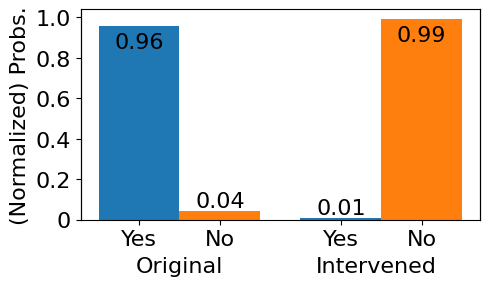

In [73]:


# Replace these with your actual numbers
yes_before = np.mean(all_yes_probs_normalized)
no_before = np.mean(all_no_probs_normalized)
yes_after = np.mean(all_yes_probs_hooked_normalized)
no_after = np.mean(all_no_probs_hooked_normalized)

# Categories and values
# categories = ["Yes", "No"]
categories = ["Original", "Intervened"]
before = [yes_before, no_before]
after = [yes_after, no_after]
values = [yes_before, no_before, yes_after, no_after]
bar_labels = ["Yes", "No", "Yes", "No"]
group_labels = ["Original", "", "Intervened", ""]

x = range(len(values))
# width = 0.35

fig, ax = plt.subplots(figsize=(5, 3))

width = 0.35
x_positions = [0, width*2+0.1, 2, width*8]
bars = ax.bar(x_positions, values, color=["tab:blue", "tab:orange", "tab:blue", "tab:orange"])
# bars1 = ax.bar([p - width / 2 for p in x], before, width, label="Before Intervention")
# bars2 = ax.bar([p + width / 2 for p in x], after, width, label="After Intervention")

for idx, bar in enumerate(bars):
    yval = bar.get_height()
    offset = 0
    if idx in [0, 3]:
        offset = -0.13
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        yval + offset,
        round(float(yval), 2),
        ha="center",
        va="bottom",
        fontsize=16,
    )

# Labels and styling
ax.set_xticks(x_positions)
ax.set_xticklabels(bar_labels, fontsize=16)

ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.tick_params(axis="x", length=0)

ax2.spines["top"].set_visible(False)
ax2.xaxis.set_ticks_position("bottom")
ax2.xaxis.set_label_position("bottom")
ax2.spines["bottom"].set_position(("axes", -0.15))
ax2.set_frame_on(True)
ax2.patch.set_visible(False)
ax2.spines["bottom"].set_visible(False)
ax2.set_xticks([0.4, 2.35])
ax2.set_xticklabels(["Original", "Intervened"], fontsize=16)
# ax.legend()

ax.set_yticklabels(["0", "0.2", "0.4", "0.6", "0.8", "1.0"], fontsize=16)

ax.set_ylabel("(Normalized) Probs.", fontsize=16)
plt.tight_layout()
fig.savefig("base_model_intervene.png", dpi=300)
fig.savefig("base_model_intervene.pdf", dpi=300)
plt.show()